# Single-Feature Clustering and Robustness Sweep — 70B (position-residualised)

**Purpose:**
1. Residualise all L1 features against `prompt_index` (removes execution-position confound).
2. Run a single-feature sweep over residualised features to identify the best discriminating feature.
3. Run a robustness sweep on that best residualised feature: for each subset size x, repeatedly
   draw x/2 emotional and x/2 neutral prompts per run, run k-means on the residualised feature,
   and record accuracy. Plot mean ± 1 SD vs x.

**Why residualise:**
Prompt index is assigned sequentially within a batch; any monotonic hardware trend (thermal
throttling, power state ramp-up) could confound condition differences. Residualising removes
the linear prompt-index effect before clustering.

## §1 — Imports and configuration

In [15]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR   = BASE_DIR / 'data' / 'shorter7b'
RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
RUNS = ['187a', '187b', '194a', '194b', '200a', '200b', '204a', '204b']

# ── L1 indicators ─────────────────────────────────────────────────────────────
L1_INDICATORS = [
    #'hat_TLB',
    #'tlb:tlb_flush',
    'core_power.throttle',
]

# ── Robustness sweep config ────────────────────────────────────────────────────
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20
N_INIT       = 50
RAND_SEED    = 42

print('Configuration OK')
print(f'  Runs         : {RUNS}')
print(f'  Subset sizes : {SUBSET_SIZES}')
print(f'  Repeats      : {N_REPEATS}')


Configuration OK
  Runs         : ['187a', '187b', '194a', '194b', '200a', '200b', '204a', '204b']
  Subset sizes : [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
  Repeats      : 20


## §2 — Load data

In [16]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'blocks{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['label'] = (df_all['condition'] == 'emotional').astype(int)

print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')


Loaded 8 runs: ['187a', '187b', '194a', '194b', '200a', '200b', '204a', '204b']
  Total trials : 320
  Emotional    : 160
  Neutral      : 160


In [17]:
print("elapsed_ms mean: ", df_all['elapsed_ms'].mean())
print("elapsed_ms std: ", df_all['elapsed_ms'].std())
print("elapsed_ms median: ", df_all['elapsed_ms'].median())
print("elapsed_ms min: ", df_all['elapsed_ms'].min())
print("elapsed_ms max: ", df_all['elapsed_ms'].max())

elapsed_ms mean:  11049.824544390625
elapsed_ms std:  799.4668946721672
elapsed_ms median:  11082.942030999999
elapsed_ms min:  9606.185458
elapsed_ms max:  12383.212084


## §3 — Select L1 features

In [18]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

X_l1 = df_all[l1_cols].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]
#X_l1 = X_l1[["core_power.throttle__mean_rate", "core_power.throttle__burst_rate", "core_power.throttle__lz_complexity", "core_power.throttle__slope"]]

print(f'L1 features available: {X_l1.shape[1]}')


L1 features available: 10


## §4 — Residualise all L1 features against `prompt_index` and `elapsed_ms`

For each feature, fit a multiple linear regression on `prompt_index` and `elapsed_ms` and
subtract the fitted values.

**Why include `elapsed_ms`:**  
`elapsed_ms` (response duration) correlates strongly with the top features — e.g.
`core_power.throttle__lz_complexity` at r ≈ −0.57, `core_power.throttle__burst_rate` at
r ≈ −0.40. A longer response means more tokens generated, which drives throttle events
independently of condition. If emotional and neutral responses differ even slightly in length,
any hardware feature correlated with duration will appear to separate conditions.
Residualising removes both the linear position trend and the response-duration effect before clustering.

In [19]:
# Covariates: prompt_index and elapsed_ms (centred for numerical stability)
cov_pos = df_all['prompt_index'].values.astype(float)
cov_ms  = df_all['elapsed_ms'].values.astype(float)
cov_pos_c = cov_pos - cov_pos.mean()
cov_ms_c  = cov_ms  - cov_ms.mean()

# Design matrix: [intercept, prompt_index, elapsed_ms]
A = np.column_stack([np.ones(len(df_all)), cov_pos_c, cov_ms_c])

# Quick check: how much do elapsed_ms and prompt_index correlate?
r_ms_pos = np.corrcoef(cov_pos_c, cov_ms_c)[0, 1]
print(f'corr(prompt_index, elapsed_ms) = {r_ms_pos:.4f}')

# Check elapsed_ms by condition
for cond in ['emotional', 'neutral']:
    v = df_all.loc[df_all.condition == cond, 'elapsed_ms']
    print(f'  {cond:10s}  elapsed_ms: mean={v.mean():.0f}  std={v.std():.0f}  median={v.median():.0f}')

# Report feature–elapsed_ms correlations for the leading features
for feat in ['core_power.throttle__lz_complexity', 'core_power.throttle__burst_rate']:
    if feat in X_l1.columns:
        r_val = np.corrcoef(df_all['elapsed_ms'].values, X_l1[feat].fillna(X_l1[feat].median()).values)[0, 1]
        print(f'  corr({feat}, elapsed_ms) = {r_val:.4f}')

# Residualise all L1 features against both covariates
X_l1_resid = X_l1.copy()
for col in X_l1.columns:
    y_col = X_l1[col].values.astype(float)
    coefs, _, _, _ = np.linalg.lstsq(A, y_col, rcond=None)
    X_l1_resid[col] = y_col - A @ coefs

print(f'\nResidualised all L1 features against prompt_index + elapsed_ms.')
print(f'Features: {X_l1_resid.shape[1]}')
print(f'Residual means (should be ~0): min={X_l1_resid.mean().min():.4f}  max={X_l1_resid.mean().max():.4f}')

corr(prompt_index, elapsed_ms) = -0.0438
  emotional   elapsed_ms: mean=11075  std=814  median=11142
  neutral     elapsed_ms: mean=11025  std=787  median=10998
  corr(core_power.throttle__lz_complexity, elapsed_ms) = -0.4668
  corr(core_power.throttle__burst_rate, elapsed_ms) = 0.8095

Residualised all L1 features against prompt_index + elapsed_ms.
Features: 10
Residual means (should be ~0): min=-0.0021  max=0.0000


# CHECK


## §5 — Single-feature sweep on residualised features

In [20]:
MAJORITY_THRESHOLD = 0.75   # require ≥ 75% of valid runs to agree on direction

def kmeans_acc_ari(X, y, n_init=50, seed=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


y_true = df_all['label'].values
runs_unique = df_all['run'].unique()

records_resid = []
for col in X_l1_resid.columns:
    acc, ari = kmeans_acc_ari(X_l1_resid[[col]].values, y_true,
                              n_init=N_INIT, seed=RAND_SEED)
    e_mean = X_l1_resid.loc[df_all['condition'] == 'emotional', col].mean()
    n_mean = X_l1_resid.loc[df_all['condition'] == 'neutral',   col].mean()
    direction = '↑E' if e_mean > n_mean else '↑N'

    run_dirs = []
    for run in runs_unique:
        mask_run = df_all['run'] == run
        e_run = X_l1_resid.loc[mask_run & (df_all['condition'] == 'emotional'), col].mean()
        n_run = X_l1_resid.loc[mask_run & (df_all['condition'] == 'neutral'),   col].mean()
        if not (np.isnan(e_run) or np.isnan(n_run)):
            run_dirs.append('↑E' if e_run > n_run else '↑N')

    majority_dir    = max(set(run_dirs), key=run_dirs.count) if run_dirs else '?'
    n_runs_majority = sum(1 for d in run_dirs if d == majority_dir)
    n_runs_valid    = len(run_dirs)
    majority_frac   = n_runs_majority / n_runs_valid if n_runs_valid > 0 else 0.0

    records_resid.append({
        'feature':          col,
        'indicator':        indicator_of(col),
        'metric':           col.split('__')[-1],
        'accuracy':         acc,
        'ari':              ari,
        'direction':        direction,
        'runs_majority':    f'{n_runs_majority}/{n_runs_valid}',
        'majority_frac':    majority_frac,
    })

sf_resid = pd.DataFrame(records_resid).sort_values('accuracy', ascending=False).reset_index(drop=True)

# Filter to features with ≥ 75% majority agreement
sf_resid_filtered = sf_resid[sf_resid['majority_frac'] >= MAJORITY_THRESHOLD].reset_index(drop=True)

BEST_FEATURE = sf_resid_filtered.iloc[0]['feature']
BEST_ACC     = sf_resid_filtered.iloc[0]['accuracy']
BEST_ARI     = sf_resid_filtered.iloc[0]['ari']

print(f'Majority threshold : ≥{MAJORITY_THRESHOLD:.0%} of valid runs')
print(f'Features passing   : {len(sf_resid_filtered)} / {len(sf_resid)}')
print()
print(f'Best single feature (residualised, ≥{MAJORITY_THRESHOLD:.0%} majority): {BEST_FEATURE}')
print(f'  Accuracy  : {BEST_ACC:.4f}')
print(f'  ARI       : {BEST_ARI:.4f}')
print(f'  Direction : {sf_resid_filtered.iloc[0]["direction"]}')
print()
print('All features (sorted by accuracy):')
print(sf_resid[['feature', 'accuracy', 'ari', 'direction', 'runs_majority', 'majority_frac']].to_string(index=False))
print()
print(f'Features passing ≥{MAJORITY_THRESHOLD:.0%} majority:')
print(sf_resid_filtered[['feature', 'accuracy', 'ari', 'direction', 'runs_majority']].to_string(index=False))

Majority threshold : ≥75% of valid runs
Features passing   : 3 / 10

Best single feature (residualised, ≥75% majority): core_power.throttle__mean_rate
  Accuracy  : 0.5406
  ARI       : 0.0037
  Direction : ↑E

All features (sorted by accuracy):
                              feature  accuracy       ari direction runs_majority  majority_frac
       core_power.throttle__mean_rate  0.540625  0.003748        ↑E           6/8          0.750
core_power.throttle__spectral_entropy  0.540625  0.003488        ↑N           5/8          0.625
    core_power.throttle__perm_entropy  0.540625  0.003933        ↑E           5/8          0.625
           core_power.throttle__slope  0.537500  0.002502        ↑N           6/8          0.750
core_power.throttle__burst_clustering  0.515625 -0.002165        ↑N           4/8          0.500
        core_power.throttle__variance  0.509375 -0.002702        ↑N           5/8          0.625
         core_power.throttle__p90_p10  0.503125 -0.002485        ↑N        

In [28]:
from scipy.stats import mannwhitneyu

# ── Mann-Whitney U with Bonferroni correction on majority-passing features ────
print('Mann-Whitney U test with Bonferroni correction')
print(f'Features tested: {len(sf_resid_filtered)}')
alpha = 0.05
alpha_corrected = alpha / len(sf_resid_filtered) if len(sf_resid_filtered) > 0 else alpha
print(f'Bonferroni-corrected alpha: {alpha_corrected:.4f}')
print()

mwu_records = []
for _, row in sf_resid_filtered.iterrows():
    feat = row['feature']
    e_vals = X_l1_resid.loc[df_all['condition'] == 'emotional', feat].dropna()
    n_vals = X_l1_resid.loc[df_all['condition'] == 'neutral',   feat].dropna()
    u, p_raw = mannwhitneyu(e_vals, n_vals, alternative='two-sided')
    p_corrected = min(p_raw * len(sf_resid_filtered), 1.0)
    sig = p_corrected < alpha
    mwu_records.append({
        'feature':       feat,
        'direction':     row['direction'],
        'runs_majority': row['runs_majority'],
        'U':             u,
        'p_raw':         p_raw,
        'p_corrected':   p_corrected,
        'significant':   'YES' if sig else 'NO',
    })

mwu_df = pd.DataFrame(mwu_records)
print(mwu_df[['feature', 'direction', 'runs_majority',
              'U', 'p_raw', 'p_corrected', 'significant']].to_string(index=False))
print()
print('Note: test applied to position-residualised feature values.')
print(f'Bonferroni correction: p_raw × {len(sf_resid_filtered)} (number of features tested).')

Mann-Whitney U test with Bonferroni correction
Features tested: 3
Bonferroni-corrected alpha: 0.0167

                       feature direction runs_majority       U    p_raw  p_corrected significant
core_power.throttle__mean_rate        ↑E           6/8 14114.0 0.112454     0.337361          NO
    core_power.throttle__slope        ↑N           6/8 11406.0 0.092194     0.276583          NO
   core_power.throttle__iat_cv        ↑N           6/8 12333.0 0.572939     1.000000          NO

Note: test applied to position-residualised feature values.
Bonferroni correction: p_raw × 3 (number of features tested).


# RAW

In [22]:
# ── Non-residualised single-feature sweep ─────────────────────────────────────
print('Non-residualised single-feature sweep')
print(f'Features: {X_l1.shape[1]}')
print()

y_true = df_all['label'].values
runs_unique = df_all['run'].unique()

records_raw = []
for col in X_l1.columns:
    acc, ari = kmeans_acc_ari(X_l1[[col]].values, y_true,
                              n_init=N_INIT, seed=RAND_SEED)
    e_mean = X_l1.loc[df_all['condition'] == 'emotional', col].mean()
    n_mean = X_l1.loc[df_all['condition'] == 'neutral',   col].mean()
    direction = '↑E' if e_mean > n_mean else '↑N'

    run_dirs = []
    for run in runs_unique:
        mask_run = df_all['run'] == run
        e_run = X_l1.loc[mask_run & (df_all['condition'] == 'emotional'), col].mean()
        n_run = X_l1.loc[mask_run & (df_all['condition'] == 'neutral'),   col].mean()
        if not (np.isnan(e_run) or np.isnan(n_run)):
            run_dirs.append('↑E' if e_run > n_run else '↑N')

    majority_dir    = max(set(run_dirs), key=run_dirs.count) if run_dirs else '?'
    n_runs_majority = sum(1 for d in run_dirs if d == majority_dir)
    n_runs_valid    = len(run_dirs)
    majority_frac   = n_runs_majority / n_runs_valid if n_runs_valid > 0 else 0.0

    records_raw.append({
        'feature':       col,
        'accuracy':      acc,
        'ari':           ari,
        'direction':     direction,
        'runs_majority': f'{n_runs_majority}/{n_runs_valid}',
        'majority_frac': majority_frac,
    })

sf_raw = pd.DataFrame(records_raw).sort_values('accuracy', ascending=False).reset_index(drop=True)

print('All features (sorted by accuracy):')
print(sf_raw[['feature', 'accuracy', 'ari', 'direction', 'runs_majority']].to_string(index=False))
print()
print(f'Best feature: {sf_raw.iloc[0].feature}  acc={sf_raw.iloc[0].accuracy:.4f}  ARI={sf_raw.iloc[0].ari:.4f}  {sf_raw.iloc[0].direction}')

Non-residualised single-feature sweep
Features: 10

All features (sorted by accuracy):
                              feature  accuracy       ari direction runs_majority
           core_power.throttle__slope  0.543750  0.004553        ↑N           6/8
        core_power.throttle__variance  0.531250  0.000823        ↑N           6/8
   core_power.throttle__lz_complexity  0.528125  0.000039        ↑N           5/8
         core_power.throttle__p90_p10  0.518750 -0.001710        ↑N           5/8
core_power.throttle__burst_clustering  0.515625 -0.002144        ↑E           6/8
      core_power.throttle__burst_rate  0.506250 -0.002987        ↑E           4/8
          core_power.throttle__iat_cv  0.503125 -0.000229        ↑N           6/8
       core_power.throttle__mean_rate  0.500000 -0.003145        ↑N           5/8
core_power.throttle__spectral_entropy  0.500000 -0.003105        ↑N           4/8
    core_power.throttle__perm_entropy  0.500000 -0.002608        ↑E           5/8

Best featu

## §6 — Robustness sweep on the best residualised feature

For each subset size x and each of the 20 repeats:
- Draw x/2 emotional and x/2 neutral **prompt indices** uniformly at random.
- Select all trials matching those prompt indices.
- Residualise the feature against prompt_index **within the subset** (same linear fit
  applied to the subset to stay self-contained).
- Run k-means and record accuracy and ARI.

In [23]:
emotional_prompts = sorted(df_all[df_all.condition == 'emotional']['prompt_index'].unique())
neutral_prompts   = sorted(df_all[df_all.condition == 'neutral']['prompt_index'].unique())

print(f'Emotional prompt indices ({len(emotional_prompts)}): {emotional_prompts}')
print(f'Neutral prompt indices   ({len(neutral_prompts)}):   {neutral_prompts}')


Emotional prompt indices (20): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Neutral prompt indices   (20):   [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


In [24]:
rng = np.random.default_rng(RAND_SEED)
results = []

for x in SUBSET_SIZES:
    half = x // 2
    assert half <= min(len(emotional_prompts), len(neutral_prompts)), \
        f'x/2={half} exceeds available prompts per condition'

    accs, aris = [], []
    for _ in range(N_REPEATS):
        e_sel = rng.choice(emotional_prompts, size=half, replace=False)
        n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

        mask = (
            ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
            ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
        )
        # Use pre-computed residuals from full dataset — do NOT re-residualise
        X_sub = X_l1_resid.loc[mask, BEST_FEATURE].values.reshape(-1, 1)
        y_sub = df_all.loc[mask, 'label'].values

        if len(np.unique(y_sub)) < 2:
            continue

        acc, ari = kmeans_acc_ari(X_sub, y_sub, n_init=N_INIT, seed=RAND_SEED)
        accs.append(acc)
        aris.append(ari)

    results.append({
        'x':        x,
        'total':    x * len(runs_loaded),
        'mean_acc': np.mean(accs),
        'std_acc':  np.std(accs),
        'mean_ari': np.mean(aris),
        'std_ari':  np.std(aris),
    })
    print(f'  x={x:2d}  total={x*len(runs_loaded):4d}  '
          f'mean_acc={np.mean(accs):.4f}  ±{np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f}')

res = pd.DataFrame(results)


  x=22  total= 176  mean_acc=0.5420  ±0.0340  mean_ARI=0.0064
  x=24  total= 192  mean_acc=0.5474  ±0.0287  mean_ARI=0.0075
  x=26  total= 208  mean_acc=0.5425  ±0.0259  mean_ARI=0.0054
  x=28  total= 224  mean_acc=0.5473  ±0.0329  mean_ARI=0.0092
  x=30  total= 240  mean_acc=0.5537  ±0.0184  mean_ARI=0.0091
  x=32  total= 256  mean_acc=0.5437  ±0.0235  mean_ARI=0.0063
  x=34  total= 272  mean_acc=0.5392  ±0.0143  mean_ARI=0.0036
  x=36  total= 288  mean_acc=0.5398  ±0.0110  mean_ARI=0.0036
  x=38  total= 304  mean_acc=0.5395  ±0.0107  mean_ARI=0.0037
  x=40  total= 320  mean_acc=0.5406  ±0.0000  mean_ARI=0.0037


## §7 — Plot

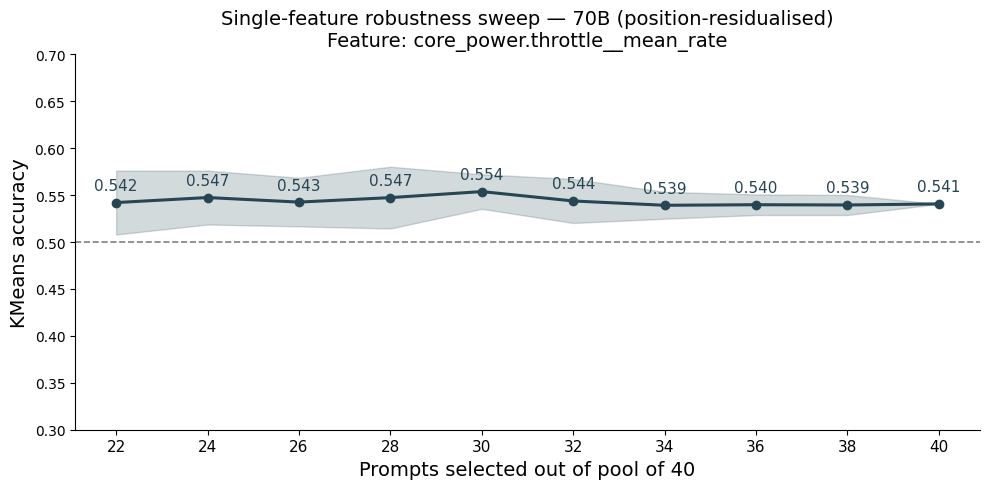

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/single_feature_robustness_70b_residualised.png


In [25]:
COLOR = '#264653'

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(xs, mean, marker='o', lw=2.2, color=COLOR, zorder=3,
        label=f'Best residualised feature: {BEST_FEATURE}')
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.20, color=COLOR, label='± 1 SD across 20 repeats')

for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', (xi, mi),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=11, color=COLOR)

ax.axhline(0.5, color='grey', lw=1.2, ls='--', label='Chance (0.50)')

ax.set_xlabel('Prompts selected out of pool of 40', fontsize=14)
ax.set_ylabel('KMeans accuracy', fontsize=14)
ax.set_title(
    f'Single-feature robustness sweep — 70B (position-residualised)\n'
    f'Feature: {BEST_FEATURE}',
    fontsize=14
)
ax.set_xticks(xs)
ax.set_xticklabels([str(xi) for xi in xs], fontsize=11)
ax.set_ylim(0.3, 0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = RESULT_DIR / 'single_feature_robustness_70b_residualised.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## §8 — Summary table

In [26]:
print('Single-feature robustness sweep — 70B (position-residualised)')
print(f'Best feature: {BEST_FEATURE}')
print(f'Full-dataset accuracy (x=40): {res[res.x==40].mean_acc.values[0]:.4f}')
print()
print(f'  {"x":>4}  {"total":>6}  {"mean acc":>9}  {"± SD":>7}  {"mean ARI":>9}  {"± SD":>7}')
print('-' * 60)
for _, r in res.iterrows():
    print(f'  {int(r.x):>4}  {int(r.total):>6}  {r.mean_acc:>9.4f}  '
          f'{r.std_acc:>7.4f}  {r.mean_ari:>9.4f}  {r.std_ari:>7.4f}')
print()
print('Chance baseline: 0.5000')


Single-feature robustness sweep — 70B (position-residualised)
Best feature: core_power.throttle__mean_rate
Full-dataset accuracy (x=40): 0.5406

     x   total   mean acc     ± SD   mean ARI     ± SD
------------------------------------------------------------
    22     176     0.5420   0.0340     0.0064   0.0204
    24     192     0.5474   0.0287     0.0075   0.0126
    26     208     0.5425   0.0259     0.0054   0.0092
    28     224     0.5473   0.0329     0.0092   0.0156
    30     240     0.5537   0.0184     0.0091   0.0078
    32     256     0.5437   0.0235     0.0063   0.0084
    34     272     0.5392   0.0143     0.0036   0.0043
    36     288     0.5398   0.0110     0.0036   0.0034
    38     304     0.5395   0.0107     0.0037   0.0035
    40     320     0.5406   0.0000     0.0037   0.0000

Chance baseline: 0.5000


## §9 — Distributions by condition — top features (after prompt_index + elapsed_ms residualisation)

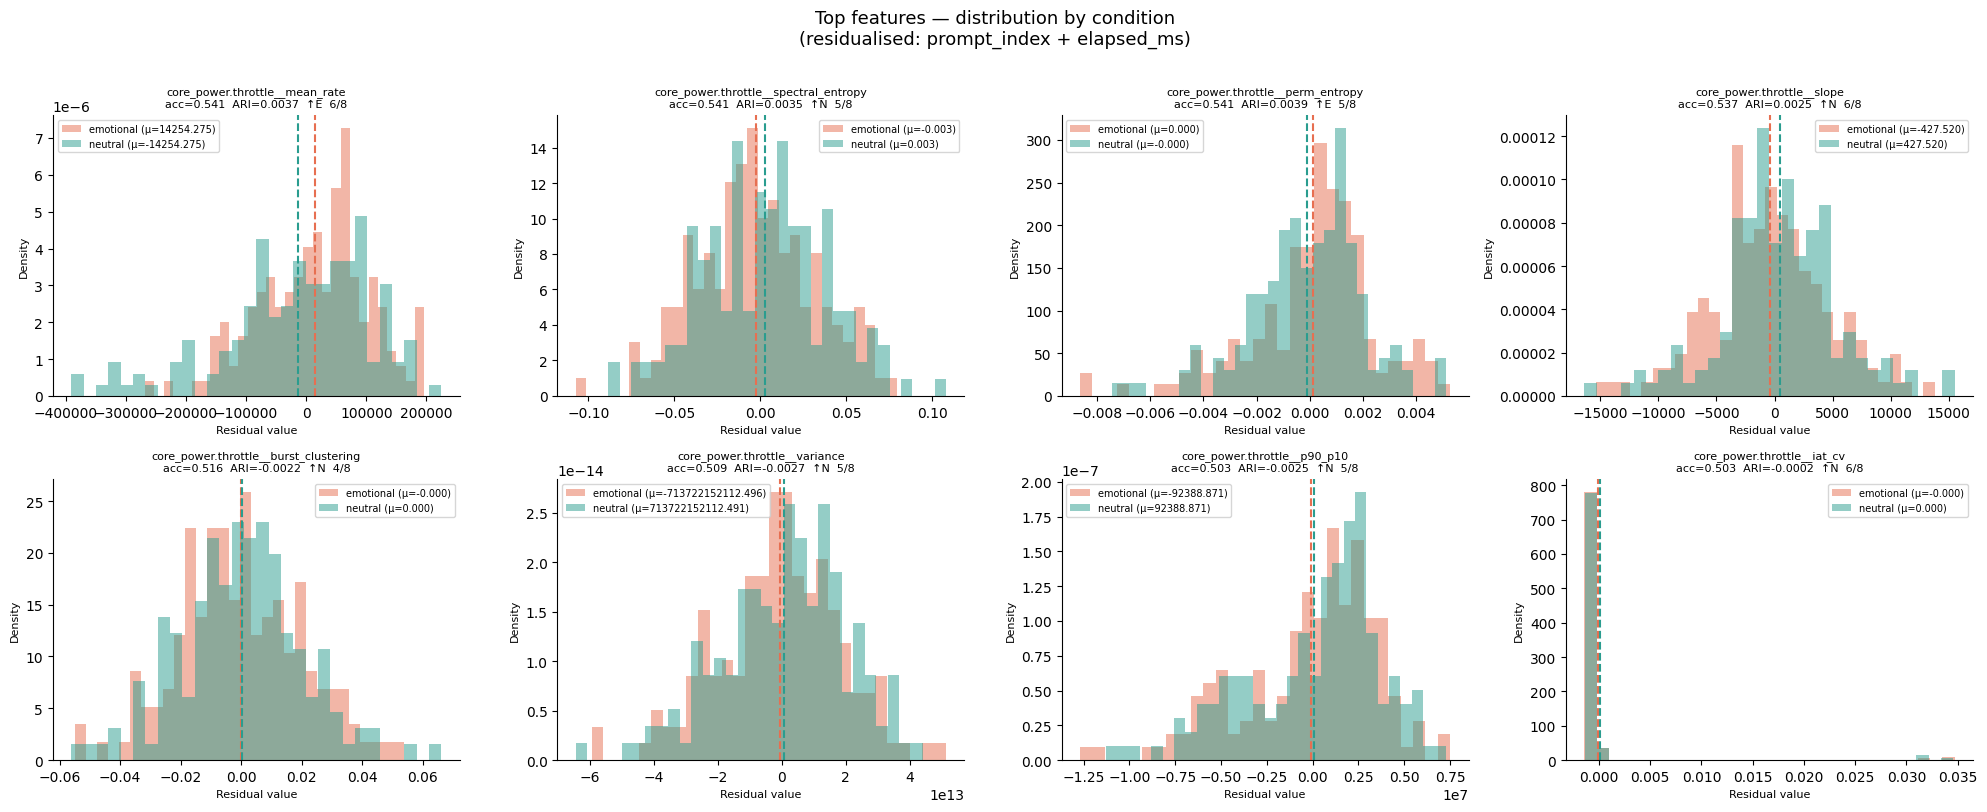

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/top_features_distribution_by_condition_70b.png

Mean (residual) by condition:
  Feature                                                   emotional     neutral        diff
  core_power.throttle__mean_rate                           14254.2752  -14254.2752  28508.5503
  core_power.throttle__spectral_entropy                       -0.0025      0.0025     -0.0051
  core_power.throttle__perm_entropy                            0.0001     -0.0001      0.0002
  core_power.throttle__slope                                -427.5204    427.5204   -855.0408
  core_power.throttle__burst_clustering                       -0.0002      0.0002     -0.0004
  core_power.throttle__variance                            -713722152112.4961  713722152112.4915  -1427444304224.9875
  core_power.throttle__p90_p10                             -92388.8714  92388.8714  -184777.7428
  core_power.throttle__iat_cv                                 -0.0001      0.0001 

In [27]:
TOP_N = 8

top_feats = sf_resid.head(TOP_N)['feature'].tolist()

n_cols = 4
n_rows = (TOP_N + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    for cond, color in [('emotional', '#e76f51'), ('neutral', '#2a9d8f')]:
        vals = X_l1_resid.loc[df_all['condition'] == cond, feat]
        e_mean = vals.mean()
        ax.hist(vals, bins=30, alpha=0.5, color=color, label=f'{cond} (μ={e_mean:.3f})', density=True)
        ax.axvline(e_mean, color=color, lw=1.5, ls='--')

    row = sf_resid[sf_resid.feature == feat].iloc[0]
    ax.set_title(
        f'{feat}\nacc={row.accuracy:.3f}  ARI={row.ari:.4f}  {row.direction}  {row.runs_majority}',
        fontsize=8
    )
    ax.set_xlabel('Residual value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

for j in range(len(top_feats), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Top features — distribution by condition\n(residualised: prompt_index + elapsed_ms)',
    fontsize=13, y=1.01
)
plt.tight_layout()
out = RESULT_DIR / 'top_features_distribution_by_condition_70b.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

# Also print summary stats per condition for each top feature
print('\nMean (residual) by condition:')
print(f'  {"Feature":55s}  {"emotional":>10}  {"neutral":>10}  {"diff":>10}')
for feat in top_feats:
    e_m = X_l1_resid.loc[df_all.condition == 'emotional', feat].mean()
    n_m = X_l1_resid.loc[df_all.condition == 'neutral',   feat].mean()
    print(f'  {feat:55s}  {e_m:10.4f}  {n_m:10.4f}  {e_m - n_m:10.4f}')